In [2]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
import os

C:\Users\hp\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model = ChatGroq(
    api_key=os.environ.get("GROQ_API_KEY"),
    model="llama-3.1-8b-instant")

In [4]:
class blogState(TypedDict):
    topic: str
    outline: str
    content: str

In [5]:
graph = StateGraph(blogState)

In [6]:
def create_outline(state: blogState) -> blogState:

    # Create a detailed outline for a blog post based on the topic provided in the state.   
    prompt = f"Create a detailed outline for a blog post about '{state['topic']}'."

    # Use the model to generate the outline based on the prompt.
    outline = model.invoke(prompt)

    # Update the state with the generated outline.
    state['outline'] = outline.content
    
    return state

In [7]:
def generate_content(state: blogState) -> blogState:

    # Generate the content for the blog post based on the outline provided in the state.
    prompt = f"Write a blog post based on the following outline:\n{state['outline']}"

    # Use the model to generate the content based on the prompt.
    content = model.invoke(prompt)

    # Update the state with the generated content.
    state['content'] = content.content
    
    return state

In [8]:
graph.add_node('create_outline', create_outline)
graph.add_node('generate_content', generate_content)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'generate_content')
graph.add_edge('generate_content', END)

workflow = graph.compile()

In [9]:
initial_state = {"topic": "GPU"}

final_state = workflow.invoke(initial_state)

In [10]:
final_state

{'topic': 'GPU',
 'outline': '**Title:** "Understanding Graphics Processing Units (GPUs): A Comprehensive Guide"\n\n**I. Introduction**\n\n* Brief overview of the importance of GPUs in computing\n* Explanation of the target audience (gamers, developers, and tech enthusiasts)\n* Thesis statement: GPUs have become an essential component in modern computing, and understanding their capabilities and applications is crucial for anyone interested in technology.\n\n**II. What is a GPU?**\n\n* Definition of a GPU and its role in processing graphics and compute tasks\n* Brief history of GPU development and evolution\n* Comparison with Central Processing Units (CPUs) and their differences\n\n**III. Types of GPUs**\n\n* Overview of the different types of GPUs:\n\t+ Integrated GPUs (iGPUs)\n\t+ Dedicated GPUs (dGPUs)\n\t+ Hybrid GPUs\n\t+ Mobile GPUs\n\t+ Cloud GPUs\n* Advantages and disadvantages of each type\n\n**IV. GPU Architecture**\n\n* Explanation of the different components of a GPU:\n\t+ 

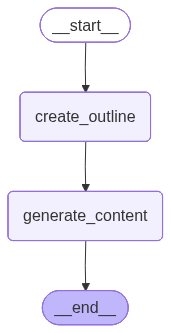

In [11]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())